In [12]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer

In [13]:
data = pd.read_csv(r"titanic.csv")

In [14]:

print(data.info())
print(data.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB
None
pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
emba

In [15]:
def detect_outliers_iqr(df, columns=None):
    if columns is None:
        columns = df.select_dtypes(include=[np.number]).columns.tolist()

    summary = []
    for column in columns:
        series = pd.to_numeric(df[column], errors="coerce")
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outlier_mask = (series < lower_bound) | (series > upper_bound)
        outliers = series[outlier_mask]

        summary.append(
            {
                "column": column,
                "q1": q1,
                "q3": q3,
                "iqr": iqr,
                "lower_bound": lower_bound,
                "upper_bound": upper_bound,
                "outlier_count": int(outliers.count()),
            }
        )

    return pd.DataFrame(summary)

survived
0    809
1    500
Name: count, dtype: int64
survived
0    61.802903
1    38.197097
Name: proportion, dtype: float64

Aykırı değer özeti:
  column       q1      q3      iqr  lower_bound  upper_bound  outlier_count
0    age  21.0000  39.000  18.0000       -6.000      66.0000              9
1   fare   7.8958  31.275  23.3792      -27.173      66.3438            171
2  sibsp   0.0000   1.000   1.0000       -1.500       2.5000             57
3  parch   0.0000   0.000   0.0000        0.000       0.0000            307


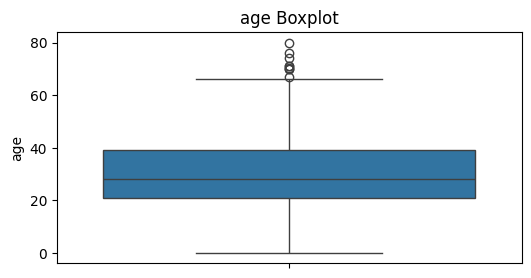

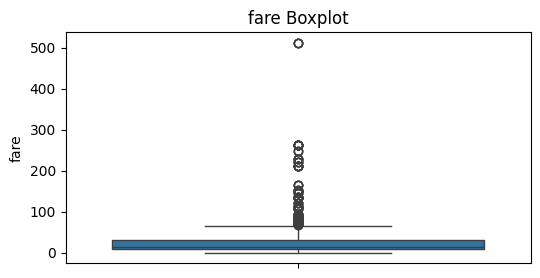

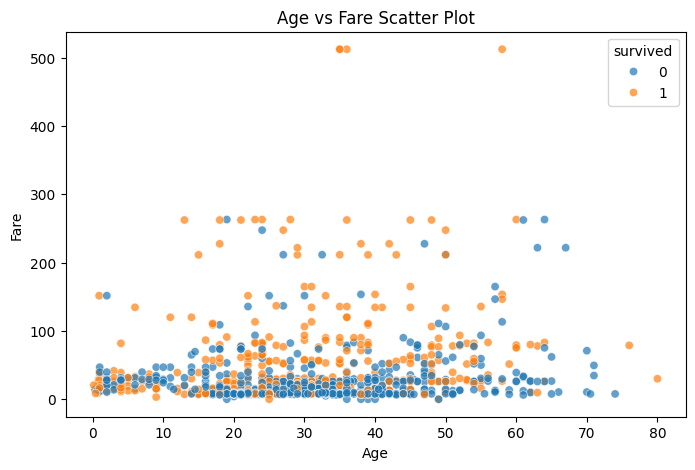

In [16]:
def plot_outlier_analysis(df, columns=None):
    if columns is None:
        columns = ["age", "fare"]

    for column in columns:
        plt.figure(figsize=(6, 3))
        sns.boxplot(y=df[column], orient="v")
        plt.title(f"{column} Boxplot")
        plt.ylabel(column)
        plt.show()

    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x="age", y="fare", hue="survived", alpha=0.7)
    plt.title("Age vs Fare Scatter Plot")
    plt.xlabel("Age")
    plt.ylabel("Fare")
    plt.savefig("age_vs_fare_scatter.png", dpi=300, bbox_inches='tight')
    plt.show()


print(data["survived"].value_counts())
print(data["survived"].value_counts(normalize=True) * 100)

outlier_summary = detect_outliers_iqr(data, columns=["age", "fare", "sibsp", "parch"])
print("\nAykırı değer özeti:")
print(outlier_summary)

plot_outlier_analysis(data)

In [17]:
def fill_na_median(df):
    df = df.copy()

    df["age"] = df["age"].fillna(df["age"].median())
    df["fare"] = df["fare"].fillna(df["fare"].median())
    df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
    df["new_hasCabin"] = df["cabin"].notna().astype(int)
    df["cabin"] = df["cabin"].fillna("Unknown")

    return df



median_data=fill_na_median(data)

In [18]:
def fill_na_knn(df):
    df = df.copy()

    numeric_columns = ["age", "fare"]

    imputer = KNNImputer(n_neighbors=5)

    df[numeric_columns] = imputer.fit_transform(df[numeric_columns])

    df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
    df["new_hasCabin"] = df["cabin"].notna().astype(int)
    df["cabin"] = df["cabin"].fillna("Unknown")

    return df


knn_data=fill_na_knn(data)

In [19]:
def feature_engineering(df):
    df = df.copy()
    df["new_AgeGroup"] = pd.cut(
        df["age"],
        bins=[0, 12, 18, 35, 60, 100],
        labels=["Child", "Teen", "Young", "Adult", "Older"],
    )
    df["new_ageSex"]=df["new_AgeGroup"].astype(str) + "_" + df["sex"].astype(str)
    df["new_cabinCount"] = df["cabin"].apply(lambda value: 0 if value == "Unknown" else len(value.split()))
    df["title"] = df["name"].str.extract(r" ([A-Za-z]+)\.")
    df["new_TravelWithGroup"] = (df.groupby("ticket")["ticket"].transform("count") > 1).astype(int)
    df["new_familySize"] = df["sibsp"] + df["parch"] + 1
    df["new_isAlone"] = (df["new_familySize"] == 1).astype(int)
    df["deck"] = df["cabin"].str[0].replace({"U": "Unknown"})
    df = df.drop(["body", "boat", "home.dest", "name", "ticket"], axis=1, errors="ignore")
    print(df.info())
    return df




median_featured = feature_engineering(median_data)
knn_featured = feature_engineering(knn_data)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   pclass               1309 non-null   int64   
 1   survived             1309 non-null   int64   
 2   sex                  1309 non-null   object  
 3   age                  1309 non-null   float64 
 4   sibsp                1309 non-null   int64   
 5   parch                1309 non-null   int64   
 6   fare                 1309 non-null   float64 
 7   cabin                1309 non-null   object  
 8   embarked             1309 non-null   object  
 9   new_hasCabin         1309 non-null   int64   
 10  new_AgeGroup         1309 non-null   category
 11  new_ageSex           1309 non-null   object  
 12  new_cabinCount       1309 non-null   int64   
 13  title                1309 non-null   object  
 14  new_TravelWithGroup  1309 non-null   int64   
 15  new_familySize       

In [21]:

def plt_show(df):
    sns.barplot(x="pclass", y="survived", data=df)
    plt.title("'Pclass'a göre hayatta kalma oranı")
    plt.xlabel("Pclass")
    plt.ylabel("Hayatta kalma oranı")
    plt.ylim(0, 1)
    plt.savefig("pclass_survival_rate.png", dpi=300, bbox_inches='tight')
    plt.show()

    pivot = df.pivot_table(
        values="survived",
        index="new_AgeGroup",
        columns="sex",
        aggfunc="mean",
        observed=False,
    )
    sns.heatmap(pivot, annot=True, cmap="Blues", vmin=0, vmax=1)
    plt.savefig("age_sex_survival.png", dpi=300, bbox_inches='tight')
    plt.show()

    non_survivors_with_group = df[
        (df["new_TravelWithGroup"] == 1) & (df["survived"] == 0)
    ]
    plt.figure(figsize=(8, 5))
    sns.countplot(x="pclass", data=non_survivors_with_group)
    plt.title("Grupla gelen ve hayatta kalamayanların Pclass dağılımı")
    plt.xlabel("Pclass")
    plt.ylabel("Kişi Sayısı")
    plt.savefig("non_survivors_with_group.png", dpi=300, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(8, 5))
    order = ["Child", "Teen", "Young", "Adult", "Older"]
    sns.barplot(x="new_AgeGroup", y="new_isAlone", data=df, order=order)
    plt.ylim(0, 1)
    plt.xlabel("Yaş Grubu")
    plt.ylabel("isAlone Oranı")
    plt.title("Yaşa göre yalnız olma oranı")
    plt.savefig("age_isAlone.png", dpi=300, bbox_inches='tight')
    plt.show()

    pivot = pd.crosstab(df["title"], df["pclass"])
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt="d")
    plt.title("Unvan ve Pclass Dağılımı")
    plt.xlabel("Pclass")
    plt.ylabel("Unvan")
    plt.savefig("title_pclass_distribution.png", dpi=300, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.heatmap(
        df.select_dtypes(include="number").corr(),
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
    )
    plt.title("Correlation Heatmap")
    plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')
    plt.show()

    pivot = pd.crosstab(df["pclass"], df["new_hasCabin"])
    pivot = pivot.rename(index={1: "1st", 2: "2nd", 3: "3rd"}, columns={0: "No", 1: "Yes"})
    plt.figure(figsize=(8, 5))
    sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt="d")
    plt.xlabel("Has Cabin")
    plt.ylabel("Pclass")
    plt.title("Pclass vs Has Cabin")
    plt.savefig("pclass_vs_has_cabin.png", dpi=300, bbox_inches='tight')
    plt.show()

    deck_stats = (
        df.groupby("deck")
        .agg(
            survival_rate=("survived", "mean"),
            count=("survived", "size"),
        )
        .reset_index()
        .sort_values("survival_rate", ascending=False)
    )

    plt.figure(figsize=(8, 5))
    plt.scatter(
        deck_stats["count"],
        deck_stats["survival_rate"],
        s=deck_stats["count"] * 5,
        alpha=0.7,
    )
    for _, row in deck_stats.iterrows():
        plt.annotate(
            row["deck"],
            (row["count"], row["survival_rate"]),
            textcoords="offset points",
            xytext=(0, 6),
            ha="center",
        )
    plt.xlabel("Kişi Sayısı")
    plt.ylabel("Yaşama Oranı")
    plt.title("Güverteye göre yaşama oranı")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.savefig("deck_survival_rate.png", dpi=300, bbox_inches='tight')
    plt.show()

    unknown = df[df["cabin"] == "Unknown"]
    plt.figure(figsize=(6, 4))
    sns.countplot(x="pclass", data=unknown, order=[1, 2, 3])
    plt.title("Cabin 'Unknown' olan yolcuların Pclass dağılımı")
    plt.xlabel("Pclass")
    plt.ylabel("Kişi Sayısı")
    plt.savefig("unknown_cabin_pclass.png", dpi=300, bbox_inches='tight')
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df["age"].dropna(), bins=30, edgecolor="black", ax=axes[0])
    axes[0].set_title("Age Distribution (Before Scaling)")

    sns.histplot(df["fare"].dropna(), bins=30, edgecolor="black", ax=axes[1])
    axes[1].set_title("Fare Distribution (Before Scaling)")

    plt.tight_layout()
    plt.savefig("age_fare_distributions.png", dpi=300, bbox_inches='tight')
    plt.show()

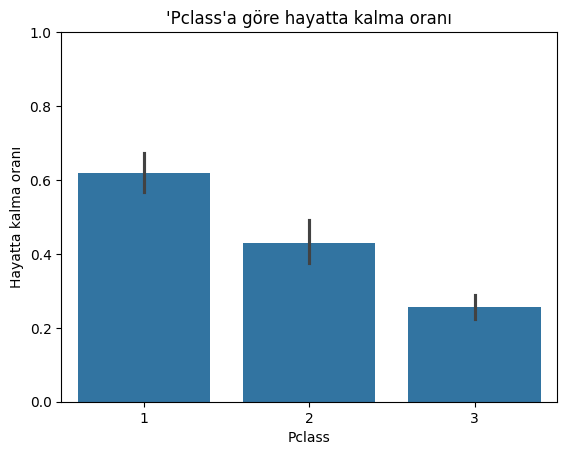

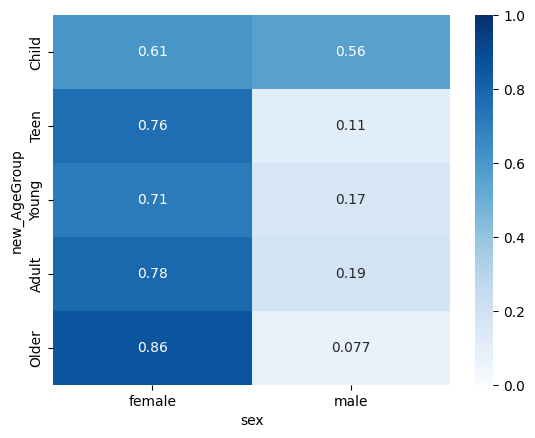

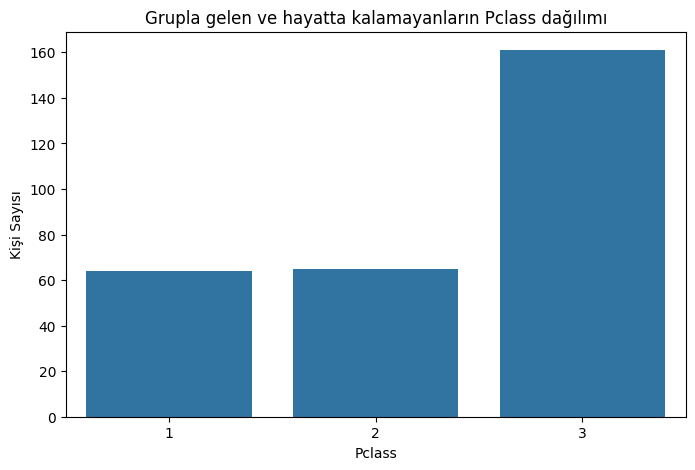

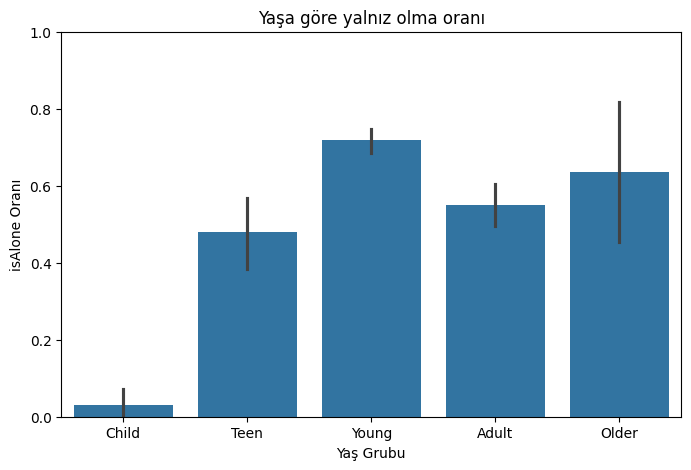

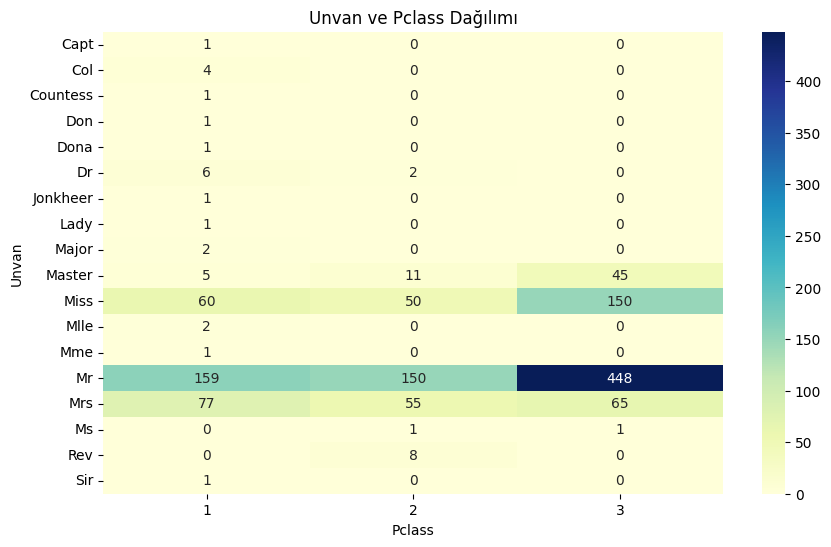

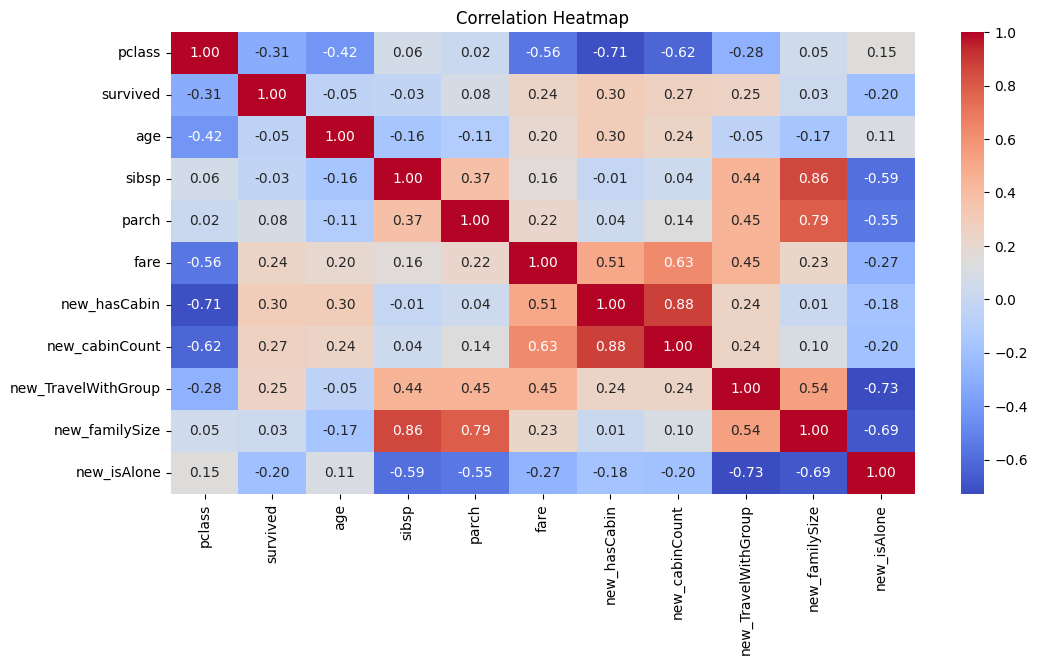

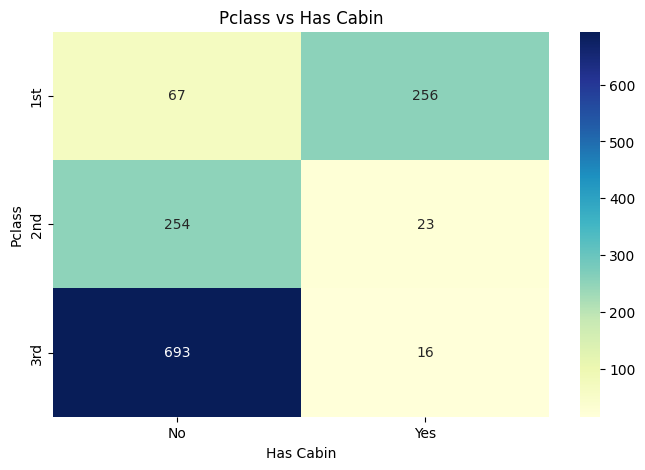

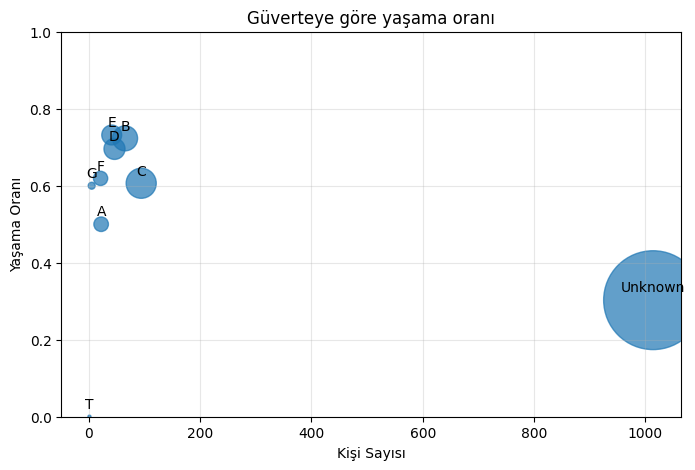

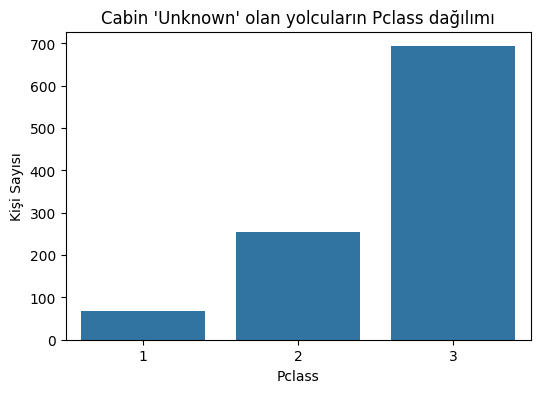

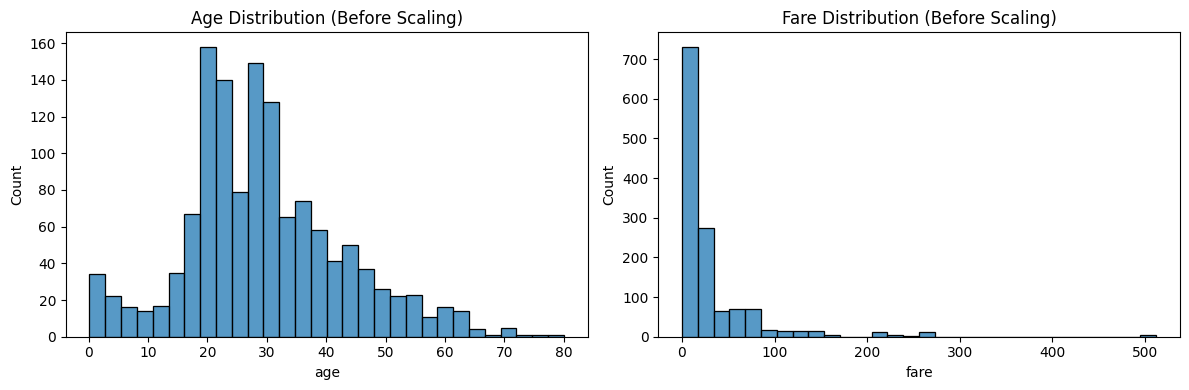

In [22]:
plt_show(knn_featured)


preprocessing

In [23]:
def preprocess(df):
    df = df.copy()
    df["sex"] = LabelEncoder().fit_transform(df["sex"])
    df[["age", "fare"]] = StandardScaler().fit_transform(df[["age", "fare"]])
    df = pd.get_dummies(df, columns=["pclass", "embarked", "new_ageSex", "deck"], dtype=int)
    return df


In [24]:
median_processed = preprocess(median_featured)
knn_processed = preprocess(knn_featured)

In [25]:
def train_test_split_data(df,method):
    features=["sex",
        "age",
        "sibsp",
        "parch",
        "fare",
        "new_hasCabin",
        "new_cabinCount",
        "new_familySize",
        "new_isAlone",
        "new_TravelWithGroup",]

    features += [
        column
        for column in df.columns
        if column.startswith(("pclass_", "embarked_", "new_ageSex_", "deck_"))
    ]

    X = df[features]
    y = df["survived"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y,
    )

    print(f"\n{method}")
    print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

    return X_train, X_test, y_train, y_test

In [27]:
median_split = train_test_split_data(
    median_processed,
    "Median Imputation",
)
knn_split = train_test_split_data(
    knn_processed,
    "KNN Imputation",
)




Median Imputation
(1047, 35) (262, 35) (1047,) (262,)

KNN Imputation
(1047, 35) (262, 35) (1047,) (262,)


In [28]:

def raw_knn_train_test_split(df, method="Raw Data - KNN Imputation"):
    df = df.copy()

    features = [
        "pclass",
        "sex",
        "age",
        "sibsp",
        "parch",
        "fare",
        "embarked",
    ]

    X = df[features]
    y = df["survived"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y,
    )

    X_train = X_train.copy()
    X_test = X_test.copy()

    embarked_mode = X_train["embarked"].mode()[0]
    X_train["embarked"] = X_train["embarked"].fillna(embarked_mode)
    X_test["embarked"] = X_test["embarked"].fillna(embarked_mode)

    imputer = KNNImputer(n_neighbors=5)
    X_train[["age", "fare"]] = imputer.fit_transform(X_train[["age", "fare"]])
    X_test[["age", "fare"]] = imputer.transform(X_test[["age", "fare"]])

    sex_mapping = {"male": 0, "female": 1}
    X_train["sex"] = X_train["sex"].map(sex_mapping)
    X_test["sex"] = X_test["sex"].map(sex_mapping)

    X_train = pd.get_dummies(
        X_train,
        columns=["pclass", "embarked"],
        dtype=int,
    )
    X_test = pd.get_dummies(
        X_test,
        columns=["pclass", "embarked"],
        dtype=int,
    )

    X_train, X_test = X_train.align(
        X_test,
        join="left",
        axis=1,
        fill_value=0,
    )

    scaler = StandardScaler()
    X_train[["age", "fare"]] = scaler.fit_transform(X_train[["age", "fare"]])
    X_test[["age", "fare"]] = scaler.transform(X_test[["age", "fare"]])

    print(f"\n{method}")
    print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

    return X_train, X_test, y_train, y_test


In [29]:
raw_knn_split = raw_knn_train_test_split(
    data,
    "Raw Data - KNN Imputation",
)


Raw Data - KNN Imputation
(1047, 11) (262, 11) (1047,) (262,)


model eğitimi

logistic regression

In [31]:
def logistic_regression(split_data,method,threshold=0.5):
    X_train, X_test, y_train, y_test = split_data

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)

    y_pred_probability = model.predict_proba(X_test)[:, 1]
    y_prediction = (y_pred_probability >= threshold).astype(int)

    accuracy = accuracy_score(y_test, y_prediction)
    precision = precision_score(y_test, y_prediction, zero_division=0)
    recall = recall_score(y_test, y_prediction, zero_division=0)
    f1 = f1_score(y_test, y_prediction, zero_division=0)

    print(f"\n{method} - Logistic Regression Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_prediction, zero_division=0))

    cm= confusion_matrix(y_test, y_prediction)
    print("\nConfusion Matrix:")
    print(cm)


    result = {
        "Imputation": method,
        "Model": "Logistic Regression",
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
    }

    return result, model, cm


random forest

In [32]:

def random_forest(split_data, method):
    X_train, X_test, y_train, y_test = split_data

    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)

    y_prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_prediction)
    precision = precision_score(y_test, y_prediction, zero_division=0)
    recall = recall_score(y_test, y_prediction, zero_division=0)
    f1 = f1_score(y_test, y_prediction, zero_division=0)

    print(f"\n{method} - Random Forest Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_prediction, zero_division=0))

    cm= confusion_matrix(y_test, y_prediction)
    print("\nConfusion Matrix:")
    print(cm)

    result = {
        "Imputation": method,
        "Model": "Random Forest",
        "Threshold": None,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
    }

    return result, model, cm

xgboost

In [33]:

def xgboost_model(split_data, method):
    from xgboost import XGBClassifier

    X_train, X_test, y_train, y_test = split_data

    model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
    model.fit(X_train, y_train)

    y_prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_prediction)
    precision = precision_score(y_test, y_prediction, zero_division=0)
    recall = recall_score(y_test, y_prediction, zero_division=0)
    f1 = f1_score(y_test, y_prediction, zero_division=0)

    print(f"\n{method} - XGBoost Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_prediction, zero_division=0))

    cm= confusion_matrix(y_test, y_prediction)
    print("\nConfusion Matrix:")
    print(cm)

    result = {
        "Imputation": method,
        "Model": "XGBoost",
        "Threshold": None,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
    }

    return result, model, cm


eğitilen modellerin karşılaştırılıp görselleştirilmesi

In [34]:

def plot_model_comparison(results_list):
    """
    Modellerin ve imputation yöntemlerinin metriklerini (Accuracy, Precision, Recall, F1)
    karşılaştırmalı bir bar grafiği ile gösterir.
    """
    # Sonuçlar listesini DataFrame'e dönüştür
    df_results = pd.DataFrame(results_list)
    
    # Seaborn için veriyi "melt" ederek düzenle
    df_melted = df_results.melt(
        id_vars=["Imputation", "Model"], 
        value_vars=["Accuracy", "Precision", "Recall", "F1"], 
        var_name="Metric", 
        value_name="Score"
    )
    
    # Karşılaştırmayı kolaylaştırmak için x ekseni etiketi oluştur (örn: Logistic Regression (KNN))
    df_melted["Configuration"] = df_melted["Model"] + "\n(" + df_melted["Imputation"] + ")"
    
    # Grafik tasarımı
    plt.figure(figsize=(12, 7))
    sns.set_theme(style="whitegrid")
    
    # Barplot çizimi
    ax = sns.barplot(
        data=df_melted,
        x="Configuration",
        y="Score",
        hue="Metric",
        palette="muted"
    )
    
    # Barların üzerine değerlerini yazdırma
    for p in ax.patches:
        height = p.get_height()
        if height > 0: # 0 olan veya boş değerleri yazdırma
            ax.annotate(
                f'{height:.3f}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=9, color='black',
                xytext=(0, 3),
                textcoords='offset points'
            )
            
    plt.title("Performance Comparison Based on Imputation and Model Selection", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Model & Imputation Method", fontsize=12, labelpad=10)
    plt.ylabel("Score", fontsize=12)
    plt.ylim(0.0, 1.1)  # Scores are between 0 and 1, so we leave some space at the top
    plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig("model_comparison.png", dpi=300, bbox_inches='tight')
    






In [35]:

def plot_model_confusion_matrix(model_name, median_cm, knn_cm):
    """
    Belirli bir model için Median ve KNN imputation yöntemlerinin 
    Confusion Matrix'lerini yan yana (1 satır, 2 sütun) çizer.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    cms = {
        "Median Imputation": median_cm,
        "KNN Imputer": knn_cm
    }
    
    for i, (imputation_title, cm) in enumerate(cms.items()):
        ax = axes[i]
        
        # Hücre içi metinleri hazırlama (Sayılar ve Yüzdeler)
        group_names = ['Doğru Negatif (TN)', 'Yanlış Pozitif (FP)', 'Yanlış Negatif (FN)', 'Doğru Pozitif (TP)']
        group_counts = [f"{value:0.0f}" for value in cm.flatten()]
        group_percentages = [f"{value:.2%}" for value in cm.flatten()/np.sum(cm)]
        
        labels = [f"{v1}\n{v2}\n({v3})" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
        labels = np.asarray(labels).reshape(2, 2)
        
        # Isı haritası çizimi
        sns.heatmap(
            cm, 
            annot=labels, 
            fmt="", 
            cmap="Blues", 
            cbar=False, 
            ax=ax,
            annot_kws={"size": 11}
        )
        
        ax.set_title(f"{imputation_title}", fontsize=13, fontweight='bold', pad=12)
        ax.set_xlabel('Tahmin Edilen Sınıf', fontsize=11, labelpad=8)
        ax.set_ylabel('Gerçek Sınıf', fontsize=11, labelpad=8)
        ax.set_xticklabels(['Öldü (0)', 'Kurtuldu (1)'])
        ax.set_yticklabels(['Öldü (0)', 'Kurtuldu (1)'], va='center')
        
    # Her model için ayrı ana başlık
    plt.suptitle(f"{model_name} - Confusion Matrix Karşılaştırması", fontsize=16, fontweight='bold')
    
    # Başlık ve grafiklerin çakışmaması için pay bırakalım
    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.savefig(f"{model_name.lower().replace(' ', '_')}_confusion_matrix_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()


def plot_raw_vs_featured_confusion_matrix(model_name, raw_cm, featured_cm):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    cms = {
        "Raw Data + KNN": raw_cm,
        "Feature Engineered Data + KNN": featured_cm
    }

    for i, (data_title, cm) in enumerate(cms.items()):
        ax = axes[i]

        group_names = ['Doğru Negatif (TN)', 'Yanlış Pozitif (FP)', 'Yanlış Negatif (FN)', 'Doğru Pozitif (TP)']
        group_counts = [f"{value:0.0f}" for value in cm.flatten()]
        group_percentages = [f"{value:.2%}" for value in cm.flatten()/np.sum(cm)]

        labels = [f"{v1}\n{v2}\n({v3})" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
        labels = np.asarray(labels).reshape(2, 2)

        sns.heatmap(
            cm,
            annot=labels,
            fmt="",
            cmap="Blues",
            cbar=False,
            ax=ax,
            annot_kws={"size": 11}
        )

        ax.set_title(data_title, fontsize=13, fontweight='bold', pad=12)
        ax.set_xlabel('Tahmin Edilen Sınıf', fontsize=11, labelpad=8)
        ax.set_ylabel('Gerçek Sınıf', fontsize=11, labelpad=8)
        ax.set_xticklabels(['Öldü (0)', 'Kurtuldu (1)'])
        ax.set_yticklabels(['Öldü (0)', 'Kurtuldu (1)'], va='center')

    plt.suptitle(f"{model_name} - Raw vs Feature Engineered", fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.savefig(f"{model_name.lower().replace(' ', '_')}_raw_vs_featured_confusion_matrix.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_knn_only_comparison_table(results_list):
    """
    Sadece 'KNN Imputation' yöntemine ait modellerin performanslarını 
    şık bir ısı haritası (heatmap) tablosu olarak görselleştirir.
    """
    # Sonuçları DataFrame'e çevir ve sadece KNN Imputation olanları filtrele
    df = pd.DataFrame(results_list)
    df_knn = df[df["Imputation"].str.contains("KNN Imputation", case=False, na=False)].copy()
    
    # İndeks olarak Model ismini belirleyelim ve metrik sütunlarını seçelim
    df_knn["Configuration"] = df_knn["Model"] + "\n(" + df_knn["Imputation"] + ")"
    df_knn.set_index("Configuration", inplace=True)
    metrics_df = df_knn[["Accuracy", "Precision", "Recall", "F1"]]
    
    # Isı haritası (Tablo) tasarımı
    plt.figure(figsize=(12, 7))
    sns.heatmap(
        metrics_df, 
        annot=True, 
        fmt=".4f", 
        cmap="YlGnBu", 
        cbar=True, 
        linewidths=.5,
        annot_kws={"size": 12, "weight": "bold"}
    )
    
    plt.title("KNN Imputation Kullanan Modellerin Performans Karşılaştırma Tablosu", fontsize=14, fontweight='bold', pad=15)
    plt.ylabel("Algoritma", fontsize=12)
    plt.xlabel("Performans Metrikleri", fontsize=12)
    plt.xticks(fontsize=11)
    plt.yticks(rotation=0, fontsize=11)
    plt.tight_layout()
    plt.savefig("knn_imputation_performance_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()



def plot_feature_importance(model, feature_names, model_name):
    importance = model.feature_importances_
    
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })

    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=True
    )

    plt.figure(figsize=(8, 6))
    plt.barh(
        importance_df["Feature"],
        importance_df["Importance"]
    )
    plt.xlabel("Importance")
    plt.ylabel("Features")
    plt.title(f"{model_name} Feature Importance")
    plt.tight_layout()
    plt.savefig(f"{model_name.lower().replace(' ', '_')}_feature_importance.png", dpi=300, bbox_inches='tight')
    plt.show()


Median Imputation - Logistic Regression Results:
Accuracy: 0.8244
Precision: 0.7647
Recall: 0.7800
F1 Score: 0.7723

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.86       162
           1       0.76      0.78      0.77       100

    accuracy                           0.82       262
   macro avg       0.81      0.82      0.81       262
weighted avg       0.83      0.82      0.82       262


Confusion Matrix:
[[138  24]
 [ 22  78]]

KNN Imputation - Logistic Regression Results:
Accuracy: 0.8321
Precision: 0.7800
Recall: 0.7800
F1 Score: 0.7800

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       162
           1       0.78      0.78      0.78       100

    accuracy                           0.83       262
   macro avg       0.82      0.82      0.82       262
weighted avg       0.83      0.83      0.83       262


Confusion Matrix:
[[140 

c:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [16:05:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [16:05:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Median Imputation - XGBoost Results:
Accuracy: 0.8092
Precision: 0.7551
Recall: 0.7400
F1 Score: 0.7475

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.85      0.85       162
           1       0.76      0.74      0.75       100

    accuracy                           0.81       262
   macro avg       0.80      0.80      0.80       262
weighted avg       0.81      0.81      0.81       262


Confusion Matrix:
[[138  24]
 [ 26  74]]

KNN Imputation - XGBoost Results:
Accuracy: 0.7901
Precision: 0.7184
Recall: 0.7400
F1 Score: 0.7291

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.82      0.83       162
           1       0.72      0.74      0.73       100

    accuracy                           0.79       262
   macro avg       0.78      0.78      0.78       262
weighted avg       0.79      0.79      0.79       262


Confusion Matrix:
[[133  29]
 [ 26  74]]


c:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [16:05:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Raw Data - KNN Imputation - XGBoost Results:
Accuracy: 0.7901
Precision: 0.7184
Recall: 0.7400
F1 Score: 0.7291

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.82      0.83       162
           1       0.72      0.74      0.73       100

    accuracy                           0.79       262
   macro avg       0.78      0.78      0.78       262
weighted avg       0.79      0.79      0.79       262


Confusion Matrix:
[[133  29]
 [ 26  74]]


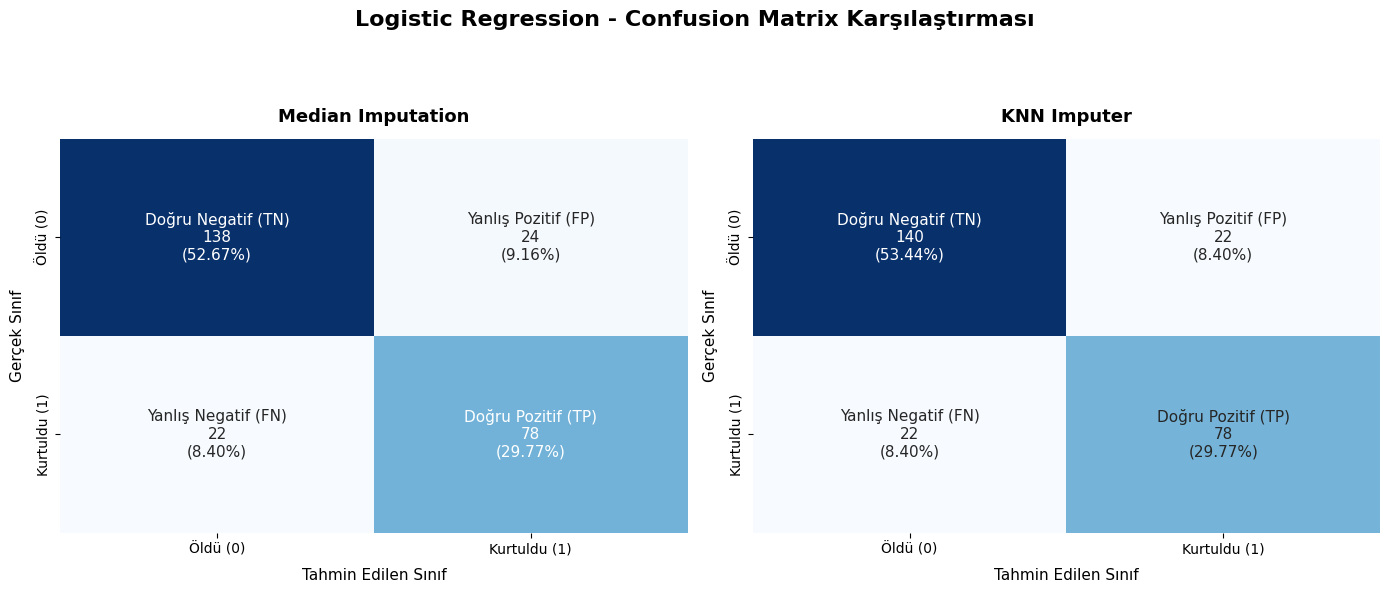

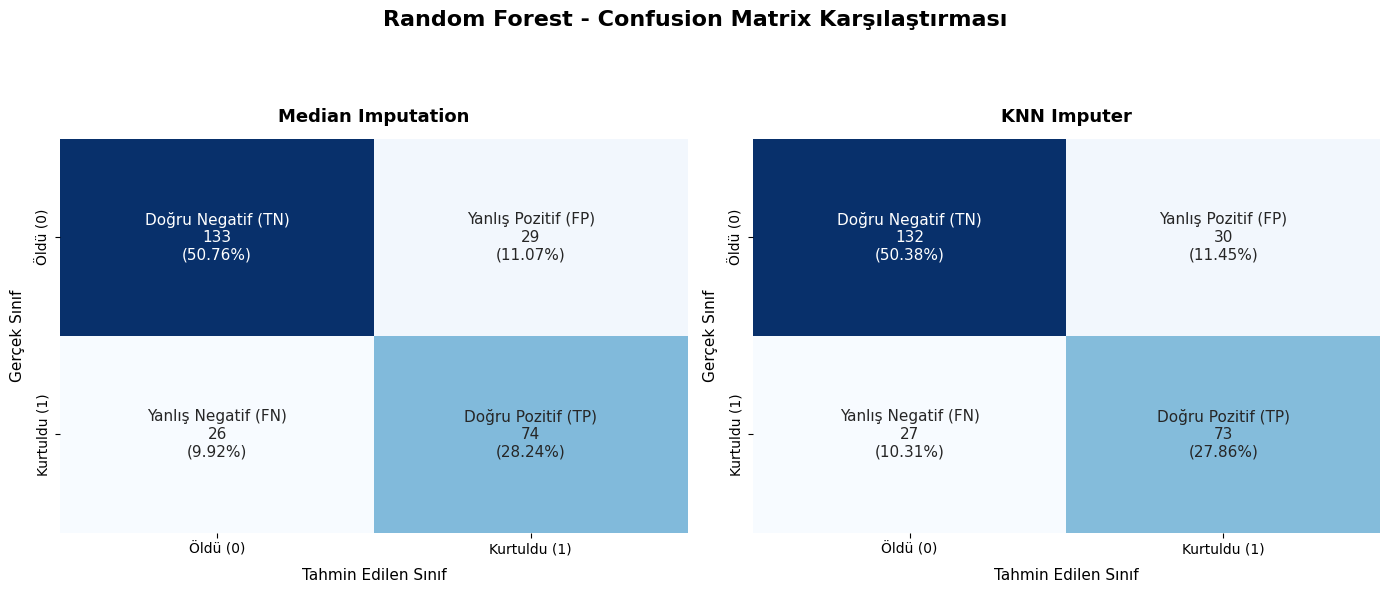

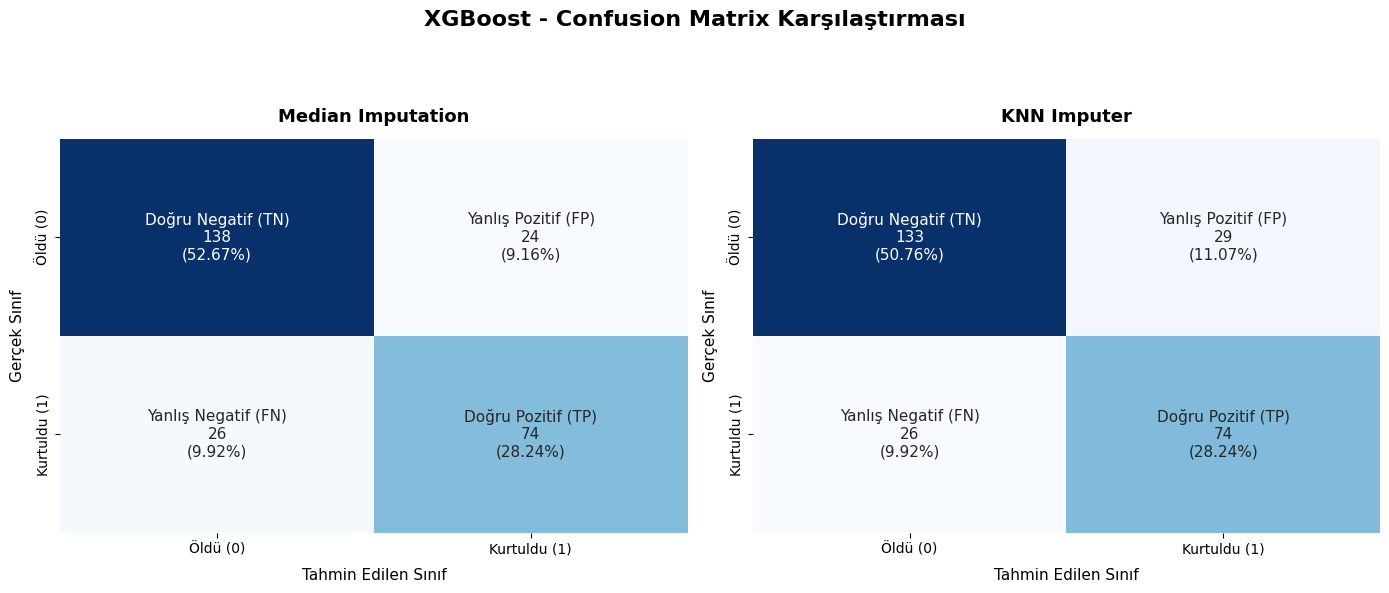

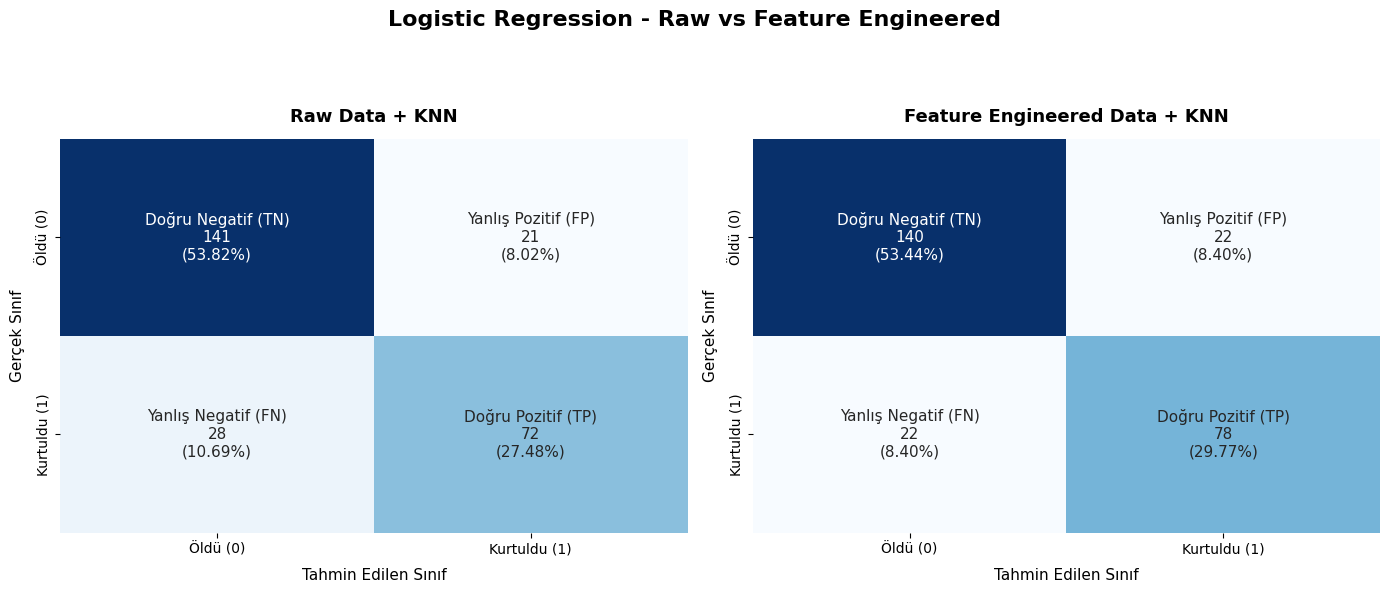

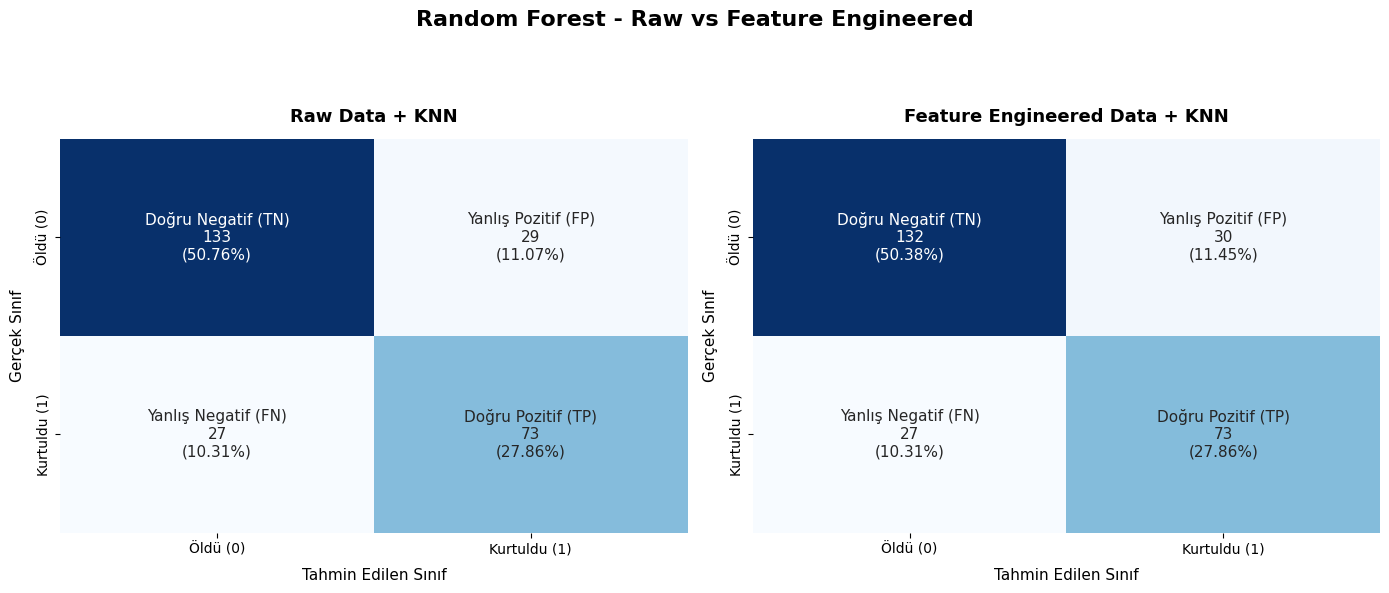

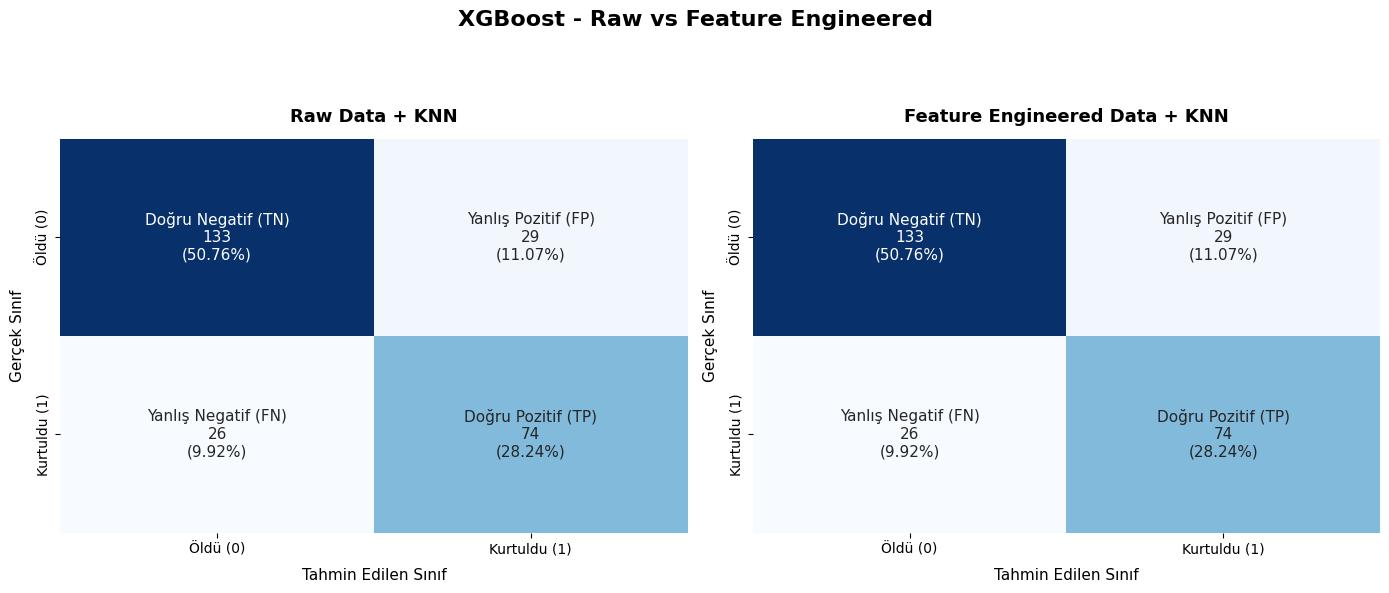

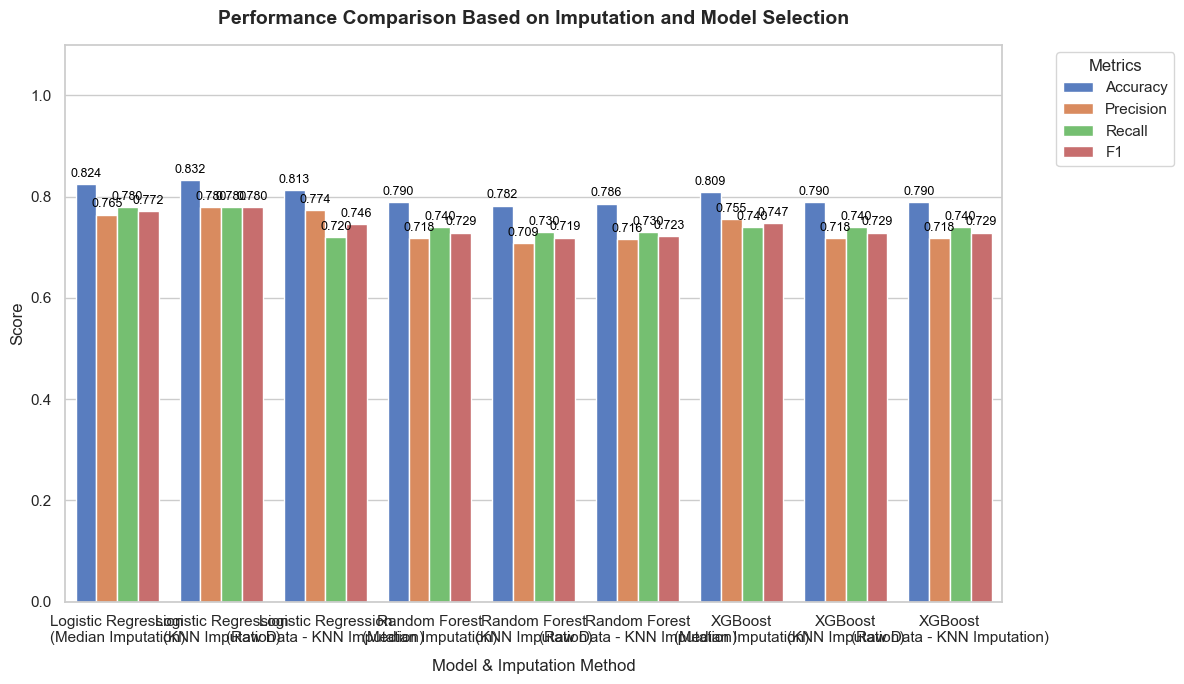

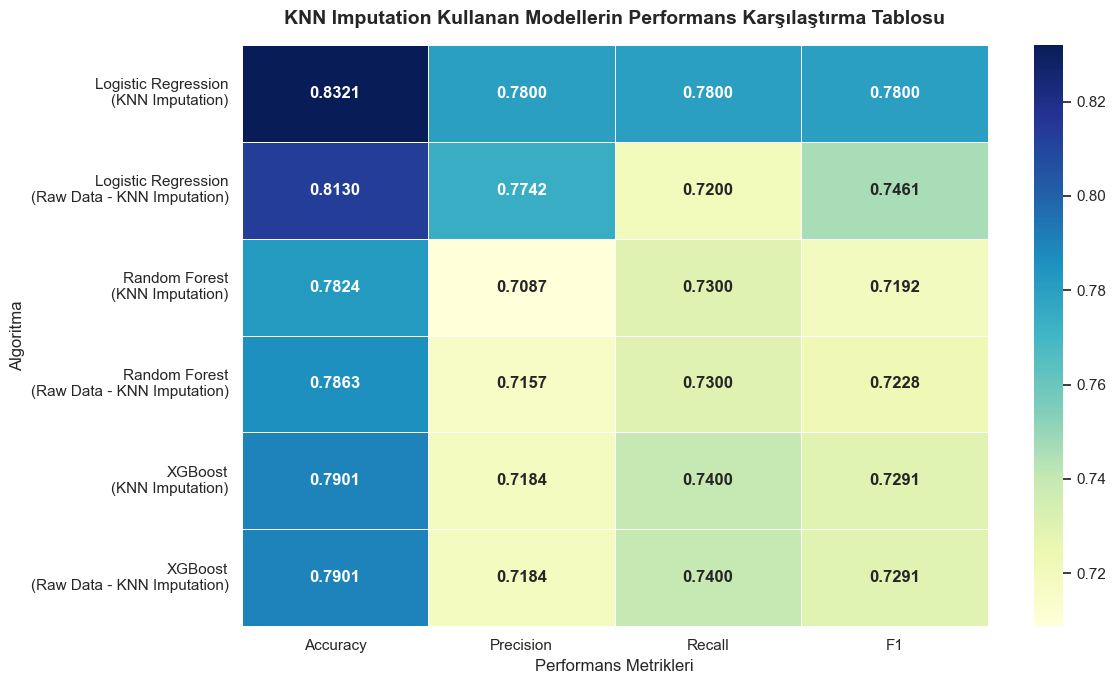

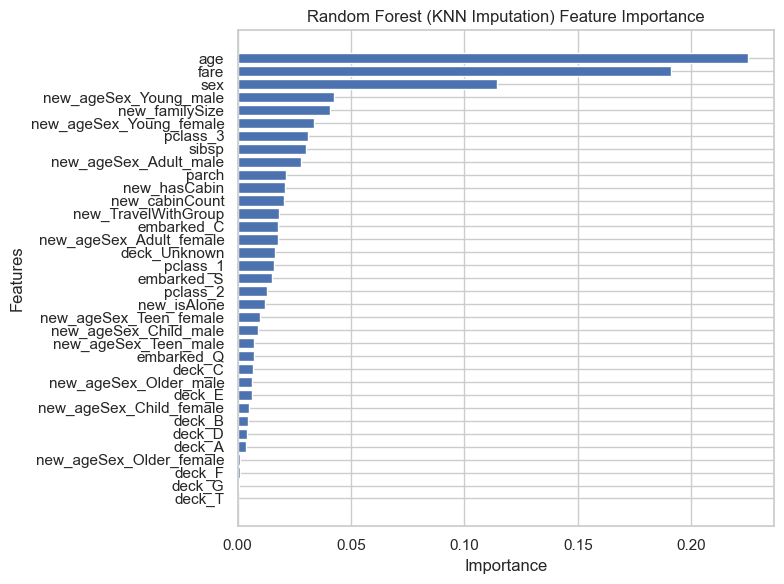

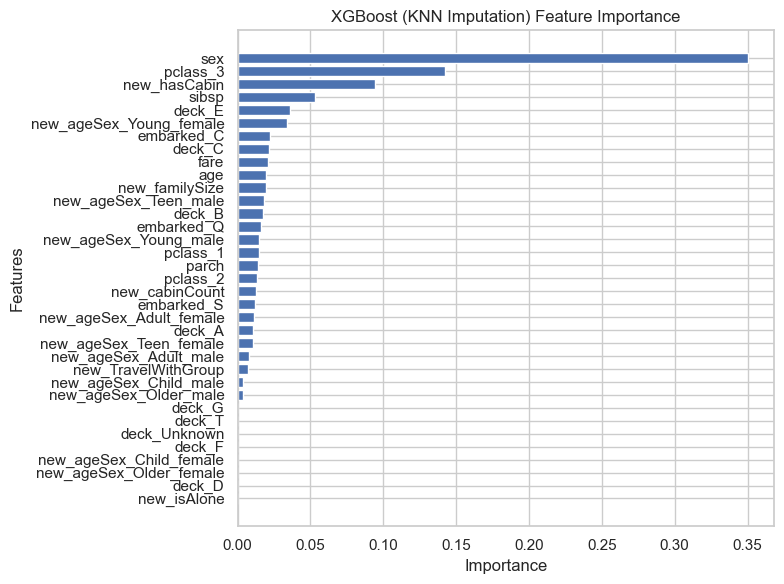

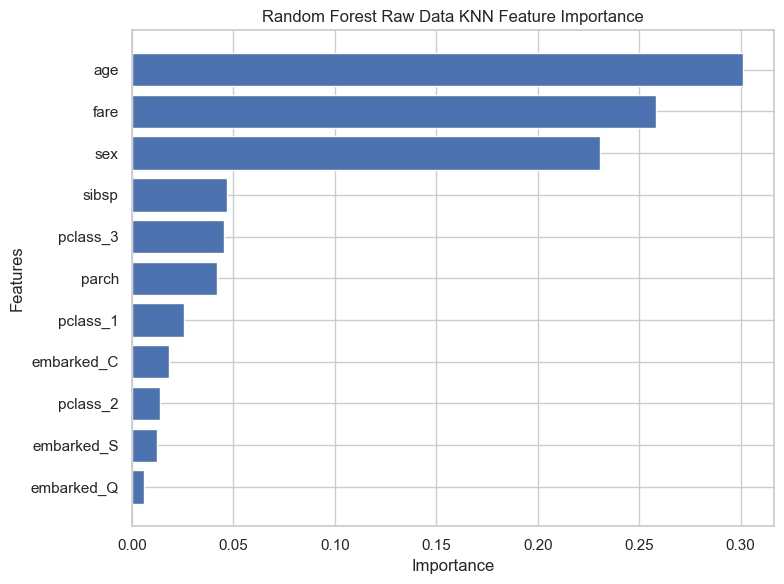

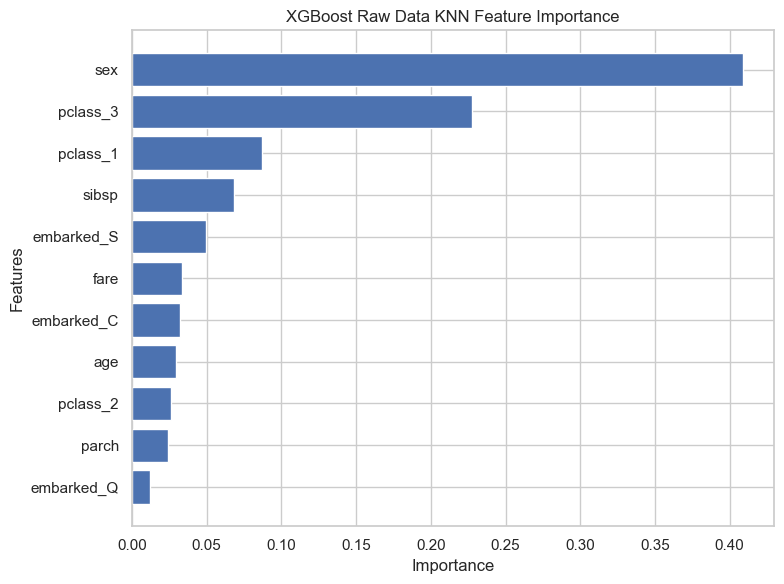

In [36]:

# --- MODEL ÇALIŞTIRMA VE HATA MATRİSLERİ ---

results = []

# 1. Logistic Regression Modelleri
median_lr_result, _, cm_med_lr = logistic_regression(
    median_split,
    "Median Imputation",
    threshold=0.5,
)
results.append(median_lr_result)

knn_lr_result, _, cm_knn_lr = logistic_regression(
    knn_split,
    "KNN Imputation",
    threshold=0.5,
)
results.append(knn_lr_result)

raw_knn_lr_result, _, cm_raw_knn_lr = logistic_regression(
    raw_knn_split,
    "Raw Data - KNN Imputation",
    threshold=0.5,
)
results.append(raw_knn_lr_result)


# 2. Random Forest Modelleri
median_rf_result, _, cm_med_rf = random_forest(
    median_split,
    "Median Imputation"
)
results.append(median_rf_result)

knn_rf_result, knn_rf_model, cm_knn_rf = random_forest(
    knn_split,
    "KNN Imputation"
)
results.append(knn_rf_result)

raw_knn_rf_result, raw_knn_rf_model, cm_raw_knn_rf = random_forest(
    raw_knn_split,
    "Raw Data - KNN Imputation"
)
results.append(raw_knn_rf_result)


# 3. XGBoost Modelleri
median_xgb_result, _, cm_med_xgb = xgboost_model(
    median_split,
    "Median Imputation"
)
results.append(median_xgb_result)

knn_xgb_result, knn_xgb_model, cm_knn_xgb = xgboost_model(
    knn_split,
    "KNN Imputation"
)
results.append(knn_xgb_result)

raw_knn_xgb_result, raw_knn_xgb_model, cm_raw_knn_xgb = xgboost_model(
    raw_knn_split,
    "Raw Data - KNN Imputation"
)
results.append(raw_knn_xgb_result)


# --- GÖRSELLEŞTİRMELER ---

# 1. Grafik: Logistic Regression Confusion Matrixleri (Median vs KNN)
plot_model_confusion_matrix("Logistic Regression", cm_med_lr, cm_knn_lr)

# 2. Grafik: Random Forest Confusion Matrixleri (Median vs KNN)
plot_model_confusion_matrix("Random Forest", cm_med_rf, cm_knn_rf)

# 3. Grafik: XGBoost Confusion Matrixleri (Median vs KNN)
plot_model_confusion_matrix("XGBoost", cm_med_xgb, cm_knn_xgb)

plot_raw_vs_featured_confusion_matrix(
    "Logistic Regression",
    cm_raw_knn_lr,
    cm_knn_lr
)

plot_raw_vs_featured_confusion_matrix(
    "Random Forest",
    cm_raw_knn_rf,
    cm_knn_rf
)

plot_raw_vs_featured_confusion_matrix(
    "XGBoost",
    cm_raw_knn_xgb,
    cm_knn_xgb
)

# 4. Grafik: Genel Performans Karşılaştırma Bar Grafiği (Tüm Modeller & Tüm Yöntemler)
plot_model_comparison(results)

# 5. Grafik: Sadece KNN Imputation Karşılaştırma Tablosu (LR vs RF vs XGBoost)
plot_knn_only_comparison_table(results)

# 6. Grafik: Random Forest Feature Importance (KNN Imputation)
plot_feature_importance(
    knn_rf_model,
    knn_split[0].columns,
    "Random Forest (KNN Imputation)"
)

# 7. Grafik: XGBoost Feature Importance (KNN Imputation)
plot_feature_importance(
    knn_xgb_model,
    knn_split[0].columns,
    "XGBoost (KNN Imputation)"
)

plot_feature_importance(
    raw_knn_rf_model,
    raw_knn_split[0].columns,
    "Random Forest Raw Data KNN"
)

plot_feature_importance(
    raw_knn_xgb_model,
    raw_knn_split[0].columns,
    "XGBoost Raw Data KNN"
)